In [26]:
# import libraries

import pandas as pd
import plotly.express as px
from pathlib import Path
import sys

In [27]:
# load data

location = Path('..') / 'src'
sys.path.append(str(location.resolve()))

from data_loader import load_all_tables, audit_tables 

tables = load_all_tables()


--- customers ---
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

--- geolocation ---
Shape: (1000163, 5)
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

--- order_items ---
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--- order_payments ---
Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--- order_reviews ---
Shape: (99224, 7)
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- orders ---
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',

In [28]:
# audit tables summary

audit_tables(tables)


DATA AUDIT SUMMARY

--- customers ---
Rows: 99,441 | Columns: 5
Nulls: None
Duplicates on 'customer_id': 0

--- geolocation ---
Rows: 1,000,163 | Columns: 5
Nulls: None
Duplicates on 'geolocation_zip_code_prefix': 981,148

--- order_items ---
Rows: 112,650 | Columns: 7
Nulls: None
Duplicates on 'order_id': 13,984

--- order_payments ---
Rows: 103,886 | Columns: 5
Nulls: None
Duplicates on 'order_id': 4,446

--- order_reviews ---
Rows: 99,224 | Columns: 7
Nulls:
  review_comment_title: 87,656 (88.3%)
  review_comment_message: 58,247 (58.7%)
Duplicates on 'review_id': 814

--- orders ---
Rows: 99,441 | Columns: 8
Nulls:
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1,783 (1.8%)
  order_delivered_customer_date: 2,965 (3.0%)
Duplicates on 'order_id': 0

--- products ---
Rows: 32,951 | Columns: 9
Nulls:
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%

In [29]:
# check date range of orders table to understand time window

ord_table = tables['orders']
print('First order:', ord_table['order_purchase_timestamp'].min())
print('Last order:', ord_table['order_purchase_timestamp'].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [30]:
# check column data types in order table

print(ord_table.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [31]:
# create new date column from datetime column and count orders per month

ord_table['order_purchase_date'] = pd.to_datetime(ord_table['order_purchase_timestamp'])
ord_table['order_purchase_month'] = ord_table['order_purchase_date'].dt.to_period('M')
monthly_orders = ord_table['order_purchase_month'].value_counts().sort_index()
monthly_orders

order_purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

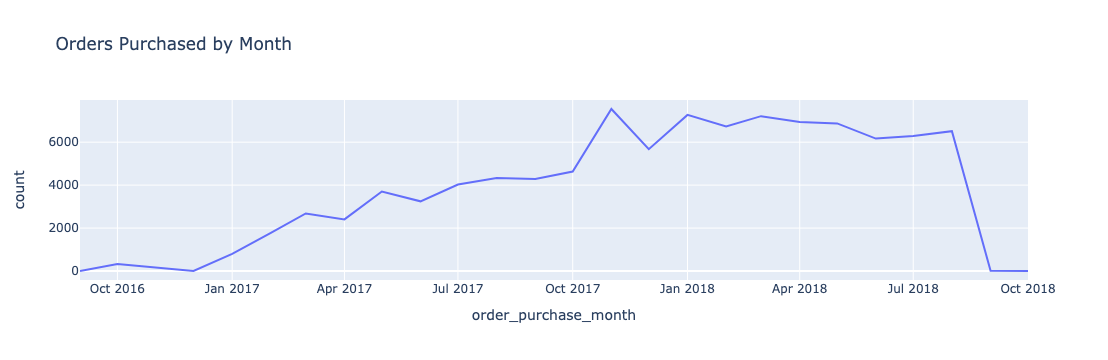

In [32]:
# time series of orders volume

monthly_orders = monthly_orders.reset_index()
monthly_orders['order_purchase_month'] = monthly_orders['order_purchase_month'].astype(str)
order_timeseries = px.line(monthly_orders, x='order_purchase_month', 
                          y='count', 
                          title='Orders Purchased by Month')
order_timeseries.show()

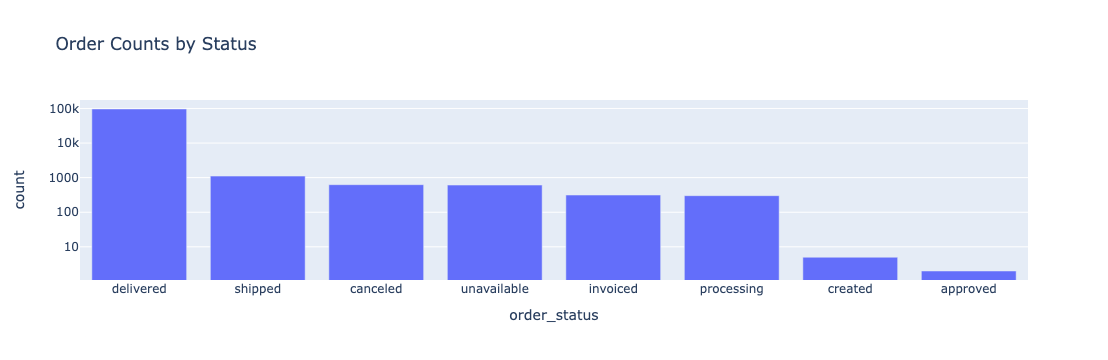

In [33]:
# order status breakdown

status_counts = ord_table['order_status'].value_counts().reset_index()
status_chart = px.bar(status_counts.sort_values('count', ascending=False),
                     x='order_status',
                     y='count',
                     title='Order Counts by Status')
status_chart.update_yaxes(type='log') # adding log scale for better visibility 
status_chart.show()

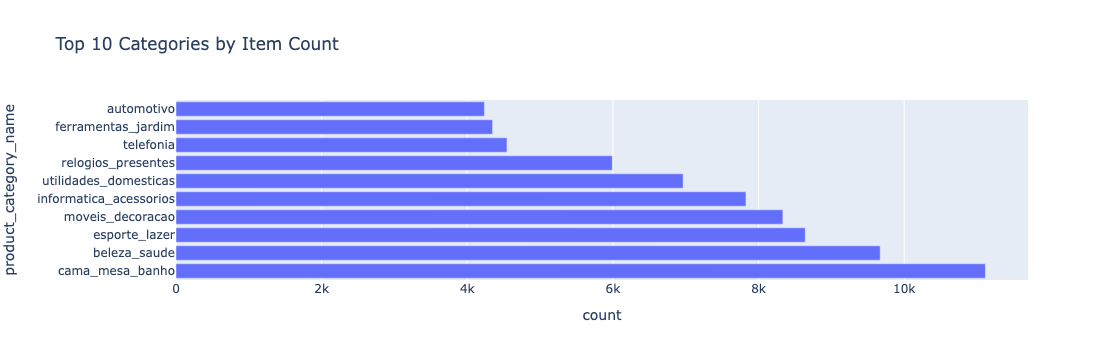

In [34]:
# top 10 categories by item count

order_items_table = tables['order_items']
products_table = tables['products']

order_items_products = order_items_table.merge(products_table, 
                                             on='product_id',
                                             how='left')
product_categories = order_items_products['product_category_name'].value_counts().reset_index()
categories_chart = px.bar(product_categories.sort_values('count', ascending=False).head(10),
                         x='count',
                         y='product_category_name',
                         title='Top 10 Categories by Item Count',
                         orientation='h')
categories_chart.show()

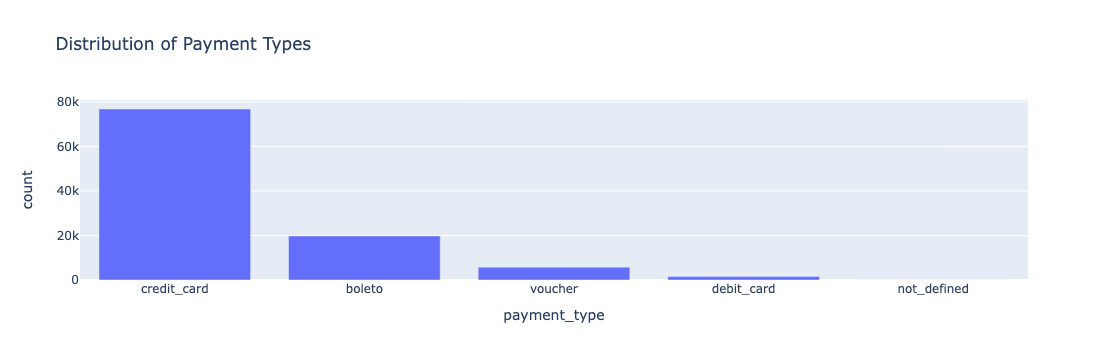

In [35]:
# payment type distribution

payments_table = tables['order_payments']
payment_types = payments_table['payment_type'].value_counts().reset_index()
payment_chart = px.bar(payment_types,
                            x='payment_type',
                            y='count',
                            title='Distribution of Payment Types')
payment_chart.show()

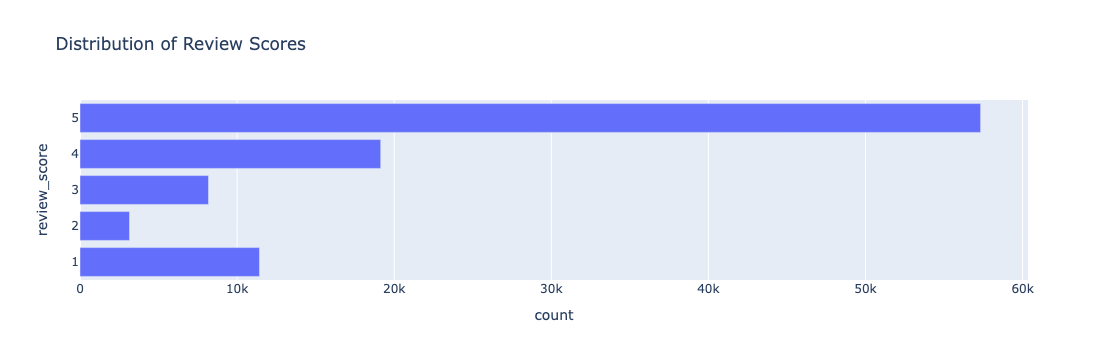

In [36]:
# review score distribution

reviews_table = tables['order_reviews']
review_scores = reviews_table['review_score'].value_counts().reset_index()
reviews_chart = px.bar(review_scores,
                      x='count',
                      y='review_score',
                      title='Distribution of Review Scores',
                      orientation='h')
reviews_chart.show()

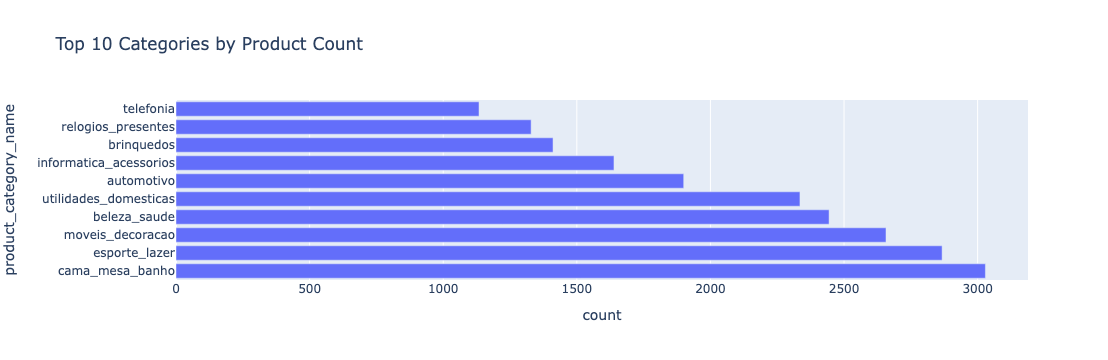

In [37]:
# top 10 categories by product count

product_category = products_table['product_category_name'].value_counts().reset_index()
product_chart = px.bar(product_category.sort_values('count',ascending=False).head(10),
                      orientation='h',
                      x='count',
                      y='product_category_name',
                      title='Top 10 Categories by Product Count')
product_chart.show()

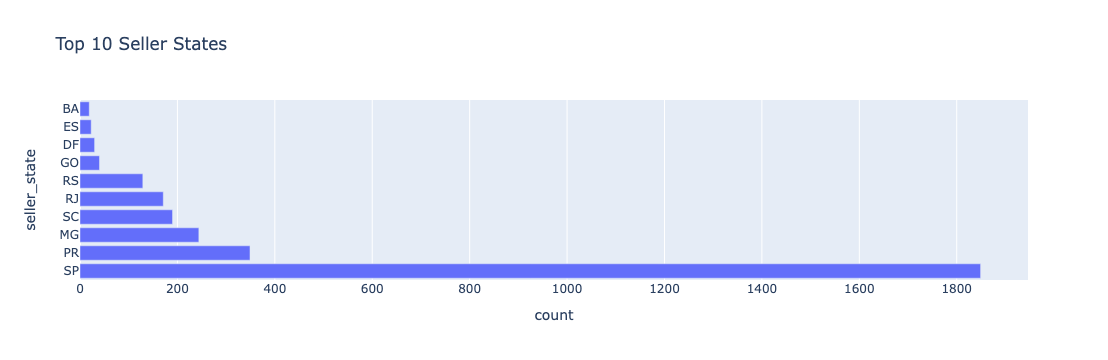

In [38]:
sellers_table = tables['sellers']
seller_states = sellers_table['seller_state'].value_counts().reset_index()
seller_state_chart = px.bar(seller_states.sort_values('count', ascending=False).head(10),
                           orientation='h',
                           x='count',
                           y='seller_state',
                           title='Top 10 Seller States')
seller_state_chart.show()

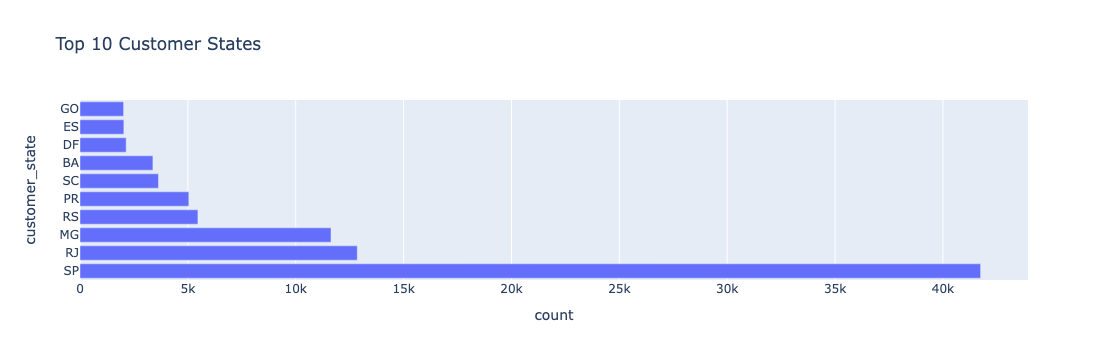

In [39]:
customers_table = tables['customers']
customer_states = customers_table['customer_state'].value_counts().reset_index()
customer_state_chart = px.bar(customer_states.sort_values('count', ascending=False).head(10),
                           orientation='h',
                           x='count',
                           y='customer_state',
                           title='Top 10 Customer States')
customer_state_chart.show()

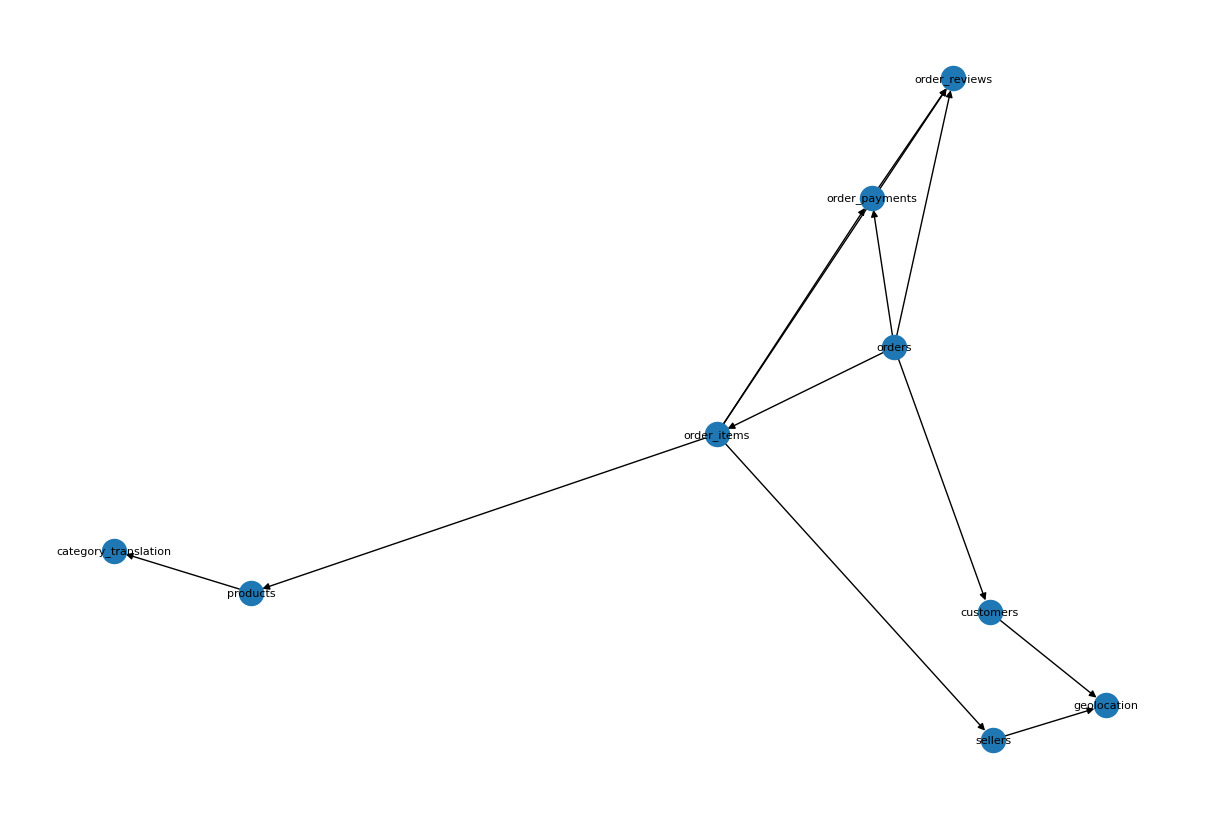

In [41]:
# create schema for the connections between tables

import networkx as nx
import matplotlib.pyplot as plt

schema = nx.DiGraph()

schema.add_node('customers')
schema.add_node('geolocation')
schema.add_node('order_items')
schema.add_node('order_payments')
schema.add_node('order_reviews')
schema.add_node('orders')
schema.add_node('products')
schema.add_node('sellers')
schema.add_node('category_translation')

schema.add_edge('orders', 'customers')
schema.add_edge('orders', 'order_items')
schema.add_edge('orders', 'order_payments')
schema.add_edge('orders', 'order_reviews')
schema.add_edge('order_items', 'products')
schema.add_edge('order_items', 'sellers')
schema.add_edge('order_items', 'order_payments')
schema.add_edge('order_items', 'order_reviews')
schema.add_edge('order_payments', 'order_reviews')
schema.add_edge('products', 'category_translation')
schema.add_edge('customers', 'geolocation')
schema.add_edge('sellers', 'geolocation')

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(schema, seed=42)
nx.draw(schema, pos=pos, with_labels=True, font_size=8)
plt.show()